# How to Predict Stock Prices Using Random Walks

The price of a stock depends on very many factors in reality that we
perceive it to be effectively random. This fact makes a random walk a
pretty good approximation to the price fluctuation of a stock over time.
In this article, we will take a first shot of predicting the seemingly
random stock price. Let’s assume that at every second, the stock price
has a 50% chance that it increases by \$0.1, and a 50% chance that it
decreases by \$0.1. Whenever we try to make meaningful predictions from
random events, we should appeal to statistics. That is, we must repeat
the time evolution of the stock price multiple times and see if we can
extract some meaningful information from it.

## Repeated time evolution of stock prices

Let’s quantify some values. We will observe the time evolution of a
stock over 1000 seconds (~17 minutes). At $t=0$, let’s assume that the
stock price is \$100. Finally, let’s repreat the experiment 5000 times.

In [81]:
import numpy as np
import matplotlib.pyplot as plt

ti, tf  = 0, 1000 # We are observing the time evolution over 1000 seconds.
price_i = 100     # We assume the initial price to be $100.
nTrials = 5000    # We are repeating the experiment 5000 times.

Let’s also define a variable named `RESULTS` that stores the stock
prices at every time step for all the trials. It will be a 2D array
where the outer axis represents the trial index and the inner axis
represents the stock price at each time for a trial. The time increments
will be stored in the variable `ts`.

In [82]:
RESULTS = np.zeros((nTrials, tf))
ts = np.arange(ti, tf, 1)

Now we need a function that does the random walk for us. We can define a
function where, given the number of steps and the initial price, it
randomly adds or subtracts 0.01 from the current price.

In [83]:
def doRandomWalk(nSteps, initial_price):
    prices = np.zeros(nSteps)
    current_price = initial_price
    for step in range(nSteps):
        prices[step] = current_price
        current_price += np.random.choice([0.1, -0.1])
    return prices

Using the ingredients above, we can now repeat the random walks.

In [84]:
for trial in range(nTrials):
    prices = doRandomWalk(tf, price_i)
    RESULTS[trial,:] = prices

It’s as simple as this! Let’s take a look at one of those trials and get
a sense of what the result looks like. I will choose, say, 318th trial
and see how the prices changed for that trial. Since the prices are
reported over 1000 seconds and 1000 entries is a bit too long, I will
print the price every 100 seconds.

In [85]:
example_trial = [round(float(p),2) for p in RESULTS[318,::100]]
print(example_trial)

[100.0, 100.4, 99.8, 100.8, 103.2, 101.8, 103.2, 102.4, 102.6, 102.8]

The price starts at \$100 as expected, and it seems to randomly walk
back and forth as time evolves. To grasp a better picture, let’s try
plotting some of the trials over time.

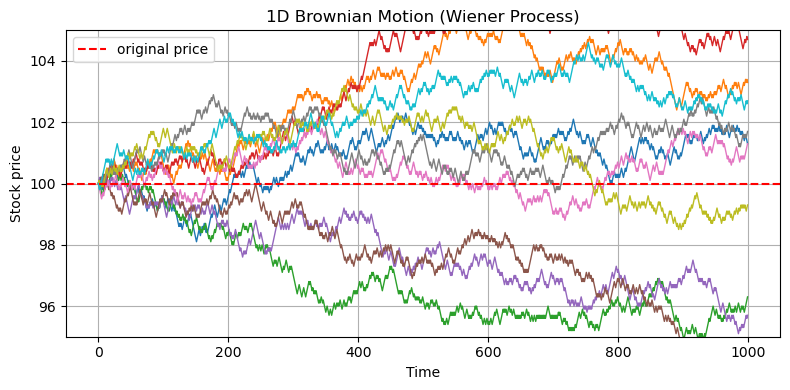

In [86]:
nTrials_to_draw = 10
price_window = [95,105]

plt.figure(figsize=(8, 4))
for prices in RESULTS[::int(nTrials/nTrials_to_draw)]:
    plt.plot(ts, prices, lw=1) # prices are floats
plt.title("1D Brownian Motion (Wiener Process)")
plt.xlabel("Time")
plt.ylabel("Stock price")
plt.ylim(price_window)
plt.grid(True)
plt.axhline(y=100, color='red', linestyle='--', label='original price')
plt.legend()
plt.tight_layout()
plt.show()

## Analyzing collective behavior

The purpose of the above plot was to simply visualize that we had
successfully simulated the stock prices as random walks. The real fun
starts now. For each time step, let’s count how many trials lie between,
say, \$99 and \$100, how many lie between \$100 and \$101, and so on.
Based on the plot above, I think it’s appropriate to count the trials
within the range $100\pm 15$ dollars. For visual purposes, I will only
show the price distribution every 100 steps.

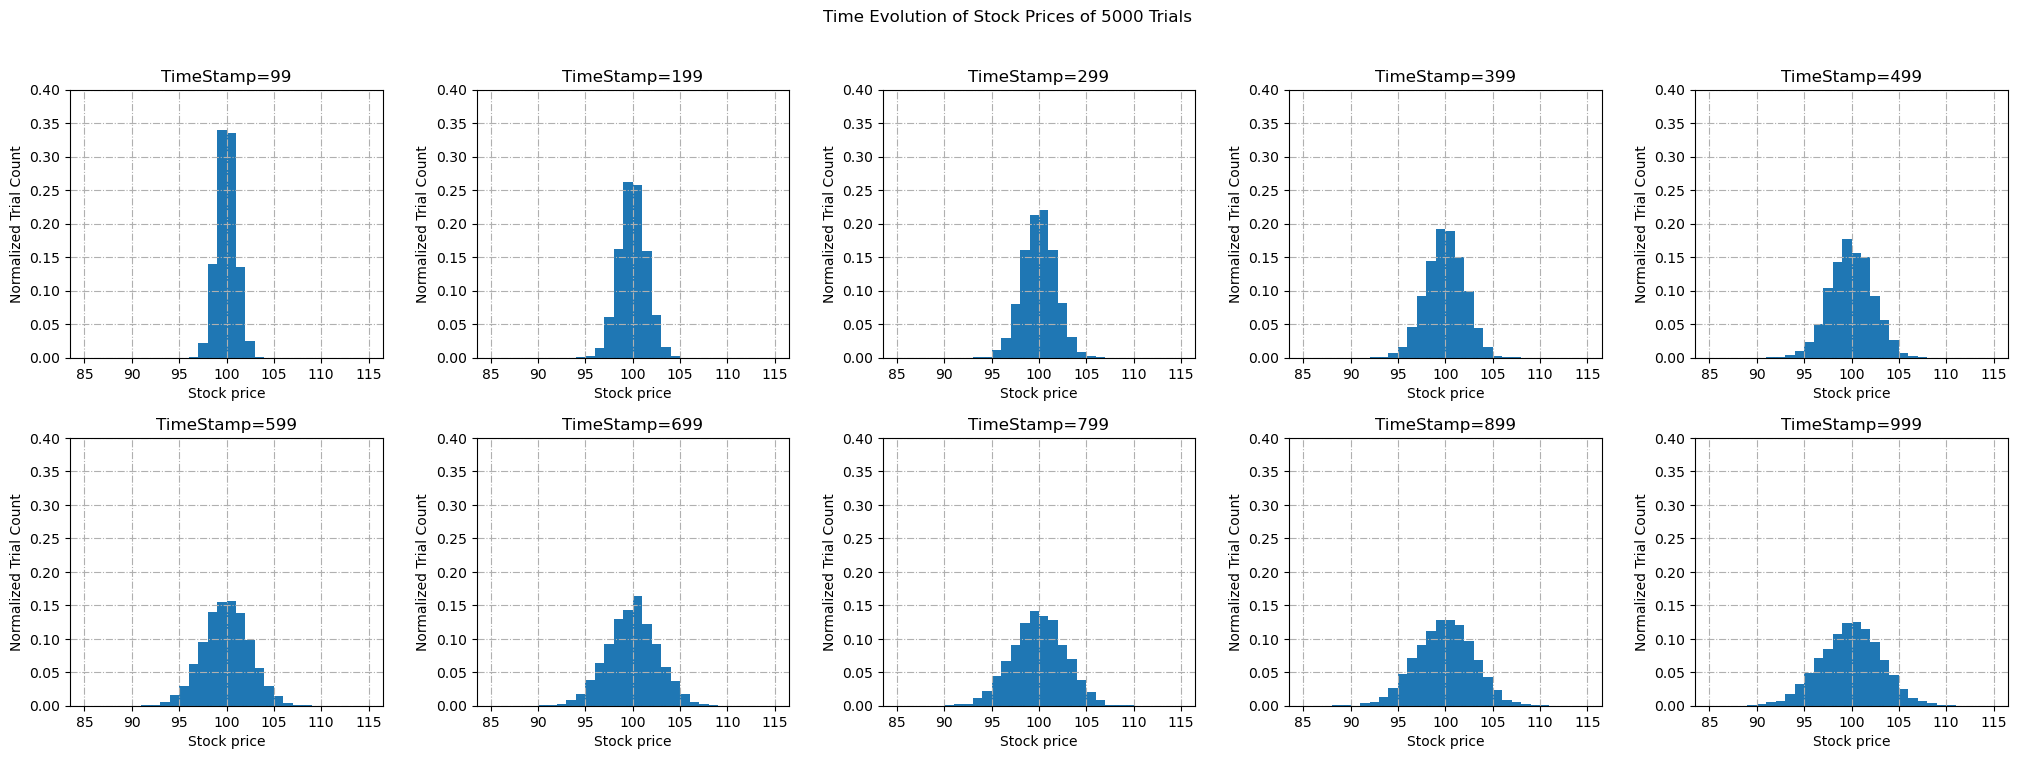

In [36]:
TimeStamps = np.arange(100, tf+1, 100)-1
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(25,8), gridspec_kw={"wspace": 0.3, "hspace": 0.3})
axes = axes.flatten()
fig.suptitle(f"Time Evolution of Stock Prices of {nTrials} Trials")
for i, t in enumerate(TimeStamps):
    ax=axes[i]
    price_dist = RESULTS[:,t]
    ax.grid(linestyle='-.')
    ax.hist(price_dist, density=True, bins=np.arange(85,116,1))
    ax.set_title(f"TimeStamp={t}")
    ax.set_ylim([0,0.4])
    ax.set_xlabel("Stock price")
    ax.set_ylabel("Normalized Trial Count")

This is fascinating! The distribution tells us that the prices tend to
spread out, or *diffuse*, as time evolves, with a mean centered around
the initial price of \$100. In physics, we model such diffusive
evolution with a differential equation called the **Heat Equation**,
where the name is motivated by how it predicts the diffusion of heat of
an object over time.

## The Heat Equation

The heat equation is given by
$$\frac{du}{dt} = \alpha\frac{d^2u}{dx^2}.$$

Although the heat equation is a second-order, parabolic partial
differential equation, it is one of the few equations that has an
analytic solution:
$$u(x,t) = \frac{1}{\sqrt{4\pi\alpha t}}\exp\left[-\frac{(x-x_i)^2}{4\alpha t}\right],$$
which is precisely a time evolving Gaussian!

### Derivation

We first move to spatial Fourier space so that we can deal with a simple
first-order linear ODE in time. Letting
$\hat{u}(k,t) = \frac{1}{\sqrt{2\pi}}\int_{-\infty}^{\infty}u(x,t)e^{-ikx}\,dx$,
we have
$$\frac{d}{dt}\hat{u}(k,t) = -\alpha k^2\hat{u}(k,t).$$
We immediately see a general solution for this equation:
$$\hat{u}(k,t) = e^{-\alpha k^2 t}\hat{u}(k,0).$$

Notice how the solution in Fourier space is a product of two functions:
i) $\hat{f}(k,0) \equiv \hat{u}(k,t)$ which is the initial condition in
Fourier space, and ii) $\hat{g} \equiv e^{-\alpha k^2 t}$, which is
sometimes called the heat kernel. We can exploit the convolution theorem
to represent this solution in physical space, which states that a
product of two functions $\hat{f}$ and $\hat{g}$ in Fourier space is a
convolution of the inverse Fourier transformed version of the functions
$f$ and $g$ in the physical space. That is, $u(x,t) = f*g$. Simply,
$\hat{f}(k,0) = f(x,0) = \delta(x-100)$, the initial condition. It is a
Dirac delta function centered at \$100. Now let’s take the inverse
Fourier transform of $\hat{g}$.

where I completed the square from the first to second line

and I took the Gaussian integral from the third line to fourth

Now we take the convolution of $f$ and $g$:

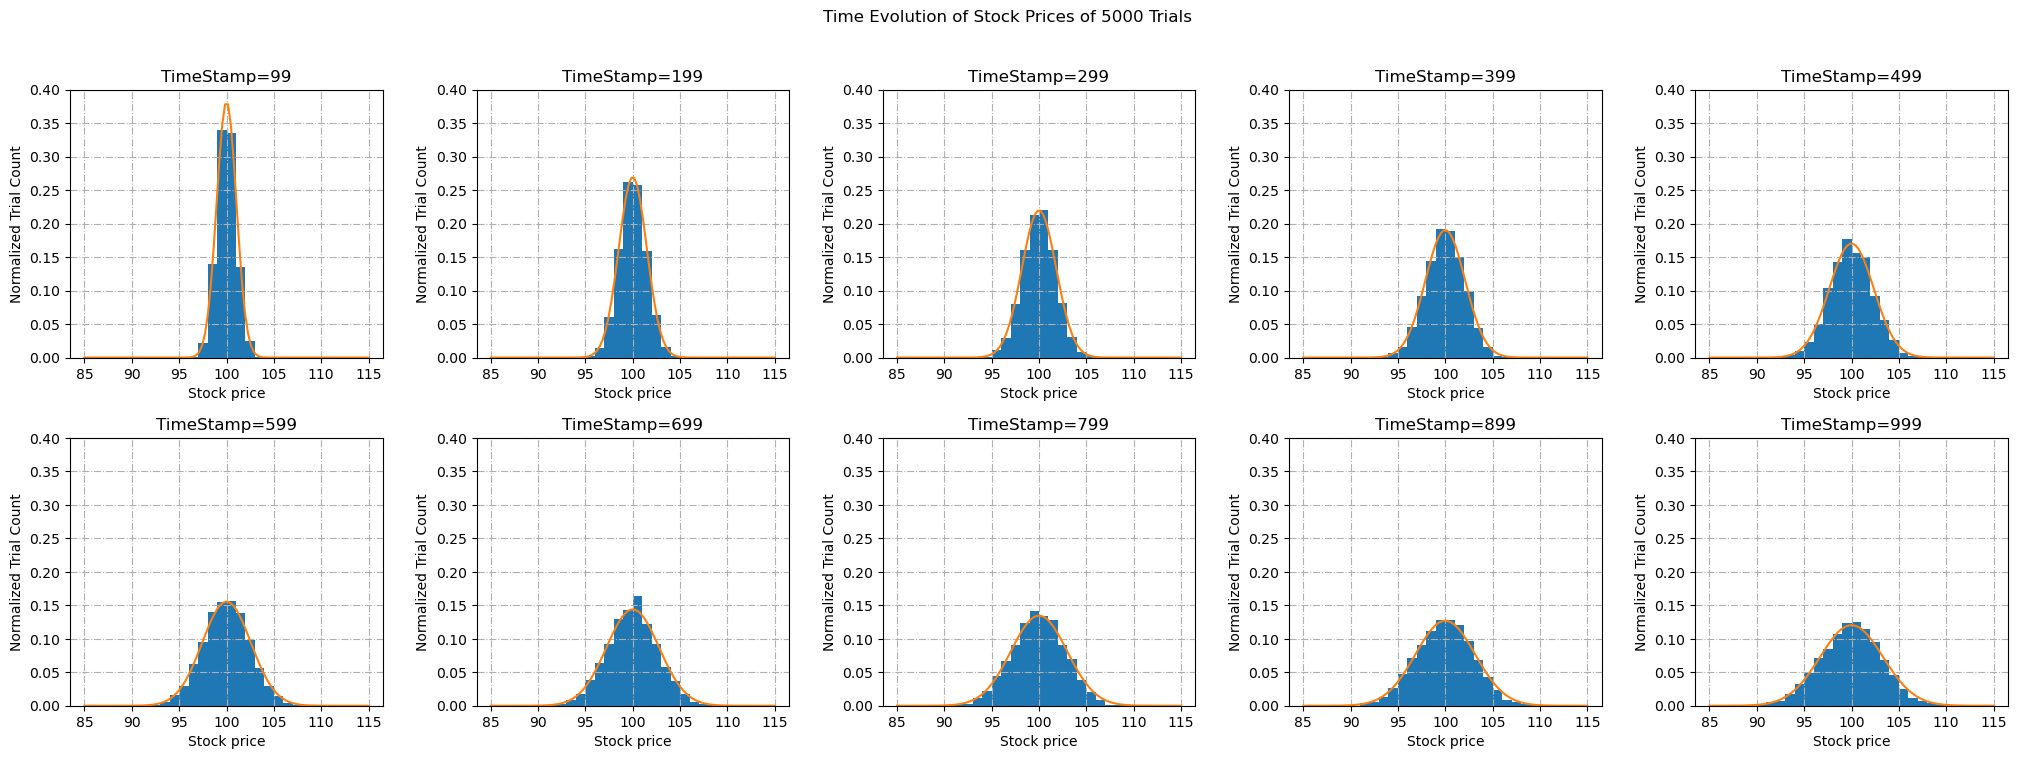

In [80]:
def Gaussian(x, t, alpha):
    return 1/np.sqrt(4*np.pi*alpha*t) * np.exp(-(x-100)**2/(4*alpha*t))

xs = np.linspace(85, 115, 100)
FITS = np.zeros((len(TimeStamps), len(xs)))
for i, t in enumerate(TimeStamps):
    fit = Gaussian(xs, t, 0.0055)
    FITS[i,:] = fit

TimeStamps = np.arange(100, tf+1, 100)-1
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(25,8), gridspec_kw={"wspace": 0.3, "hspace": 0.3})
axes = axes.flatten()
fig.suptitle(f"Time Evolution of Stock Prices of {nTrials} Trials")
for i, t in enumerate(TimeStamps):
    ax=axes[i]
    price_dist = RESULTS[:,t]
    ax.grid(linestyle='-.')
    ax.hist(price_dist, density=True, bins=np.arange(85,116,1))
    ax.plot(xs, FITS[i])

    ax.set_title(f"TimeStamp={t}")
    ax.set_ylim([0,0.4])
    ax.set_xlabel("Stock price")
    ax.set_ylabel("Normalized Trial Count")

TODO: - alpha is set to 0.0055 and it fits. Analytically derive the
volatility and find the optimal alpha value.